# Section Importation des librairies nécessaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Section Chargement et description initiale

In [2]:
# Chargement du jeu de données brut
df = pd.read_csv("../data/raw/irrigation_prediction.csv")

# Dimensions du jeu de données
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dimensions : 10000 lignes, 20 colonnes


In [3]:
# # Aperçu des premières observations
pd.set_option("display.max_columns", None)
display(df.head(10))

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium
5,Silt,5.10,20.50,0.37,1.43,33.34,62.51,402.92,7.03,13.55,Rice,Sowing,Zaid,Sprinkler,Groundwater,7.56,Yes,7.33,East,Medium
6,Sandy,7.44,22.70,0.59,2.95,28.02,58.50,764.95,7.08,7.38,Rice,Flowering,Kharif,Sprinkler,Reservoir,2.18,No,51.47,West,Medium
7,Sandy,7.68,40.23,0.62,3.30,35.60,79.10,833.33,5.17,3.73,Wheat,Vegetative,Zaid,Rainfed,Reservoir,12.54,Yes,118.96,West,Low
8,Clay,5.42,36.73,0.74,1.52,16.59,76.88,2476.03,10.34,1.80,Maize,Flowering,Kharif,Sprinkler,Rainwater,13.75,Yes,107.25,Central,Low
9,Loamy,6.26,19.58,0.36,1.67,31.14,74.30,1474.55,8.53,17.68,Rice,Vegetative,Rabi,Rainfed,Reservoir,1.27,Yes,97.92,Central,Medium


In [4]:
# Types de chaque colonne
display(df.dtypes)

Soil_Type                      str
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                      str
Crop_Growth_Stage              str
Season                         str
Irrigation_Type                str
Water_Source                   str
Field_Area_hectare         float64
Mulching_Used                  str
Previous_Irrigation_mm     float64
Region                         str
Irrigation_Need                str
dtype: object

Cette étape est indispensable avant toute analyse — elle permet de vérifier que le fichier chargé correspond bien à la structure attendue (10 000 lignes, 20 colonnes) et d'identifier d'emblée les variables numériques (à standardiser) et catégorielles (à encoder).

# Section — Préparation des données

## 1. Détection des doublons et valeurs manquantes ; Nettoyage

In [5]:
# Doublons
print(f"Nombre de doublons : {df.duplicated().sum()}")


Nombre de doublons : 0


In [6]:
# Valeurs manquantes par colonne
display(df.isnull().sum())

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [7]:
# Suppression des doublons si présents
df = df.drop_duplicates()

## 2. Encodage des variables catégorielles nominales

Le one-hot encoding est retenu car ces variables (type de sol, type de culture, région, etc.) n'ont pas d'ordre naturel — un encodage numérique simple (0, 1, 2...) introduirait artificiellement une relation d'ordre inexistante, ce qui biaiserait le Random Forest.

In [8]:
variables_categorielles = ["Soil_Type", "Crop_Type", "Season",
                            "Irrigation_Type", "Water_Source", "Mulching_Used", "Region"
]

In [9]:
# Encodage one-hot pour les variables catégorielles nominales (sans ordre)
df_encoded = pd.get_dummies(df, columns=variables_categorielles, drop_first=True)

## 3. Encodage des variables catégorielles ordinales

Contrairement aux autres variables catégorielles, Irrigation_Need et Crop_Growth_Stage possèdent un ordre naturel — un encodage ordinal (et non one-hot) est donc scientifiquement plus cohérent, et permettra en option une analyse tenant compte de la gravité des erreurs (cf. discussion précédente sur la classification ordinale).

In [10]:
ordre_stades = { "Sowing": 0, "Vegetative": 1, "Flowering": 2, "Harvest": 3}
df_encoded["Crop_Growth_Stage_Encoded"] = df["Crop_Growth_Stage"].map(ordre_stades)

# Encodage ordinal, car Low < Medium < High
ordre_classes = {"Low": 0, "Medium": 1, "High": 2}
df_encoded["Irrigation_Need_encoded"] = df["Irrigation_Need"].map(ordre_classes)

# Section — Analyse exploratoire des données

## 1. Statistiques descriptives et distributions

In [11]:
display(df.describe(include="number").T.style.format("{:.2f}"))

,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.00,6.49,0.98,4.80,5.64,6.47,7.35,8.20
Soil_Moisture,10000.00,36.97,16.43,8.00,22.86,37.24,50.94,65.00
Organic_Carbon,10000.00,0.94,0.37,0.30,0.62,0.95,1.26,1.60
Electrical_Conductivity,10000.00,1.79,0.98,0.10,0.94,1.78,2.65,3.50
Temperature_C,10000.00,26.99,8.66,12.00,19.46,27.09,34.50,42.00
Humidity,10000.00,60.08,20.19,25.00,42.86,60.04,77.70,95.00
Rainfall_mm,10000.00,1252.50,715.58,0.38,634.15,1250.34,1880.26,2499.69
Sunlight_Hours,10000.00,7.52,2.02,4.00,5.76,7.56,9.26,11.00
Wind_Speed_kmh,10000.00,10.16,5.67,0.50,5.16,10.19,15.10,20.00
Field_Area_hectare,10000.00,7.60,4.23,0.30,3.95,7.54,11.20,15.00


In [12]:
display(df.describe(include="string").T)

,count,unique,top,freq
Soil_Type,10000,4,Sandy,2536
Crop_Type,10000,6,Rice,1711
Crop_Growth_Stage,10000,4,Harvest,2581
Season,10000,3,Rabi,3383
Irrigation_Type,10000,4,Sprinkler,2527
Water_Source,10000,4,River,2528
Mulching_Used,10000,2,No,5013
Region,10000,5,South,2102
Irrigation_Need,10000,3,Low,5864


In [13]:
variables_numeriques = ["Soil_pH", "Soil_Moisture", "Organic_Carbon", 
                         "Electrical_Conductivity", "Temperature_C", "Humidity", 
                         "Rainfall_mm", "Sunlight_Hours", "Wind_Speed_kmh", 
                         "Field_Area_hectare", "Previous_Irrigation_mm"
]

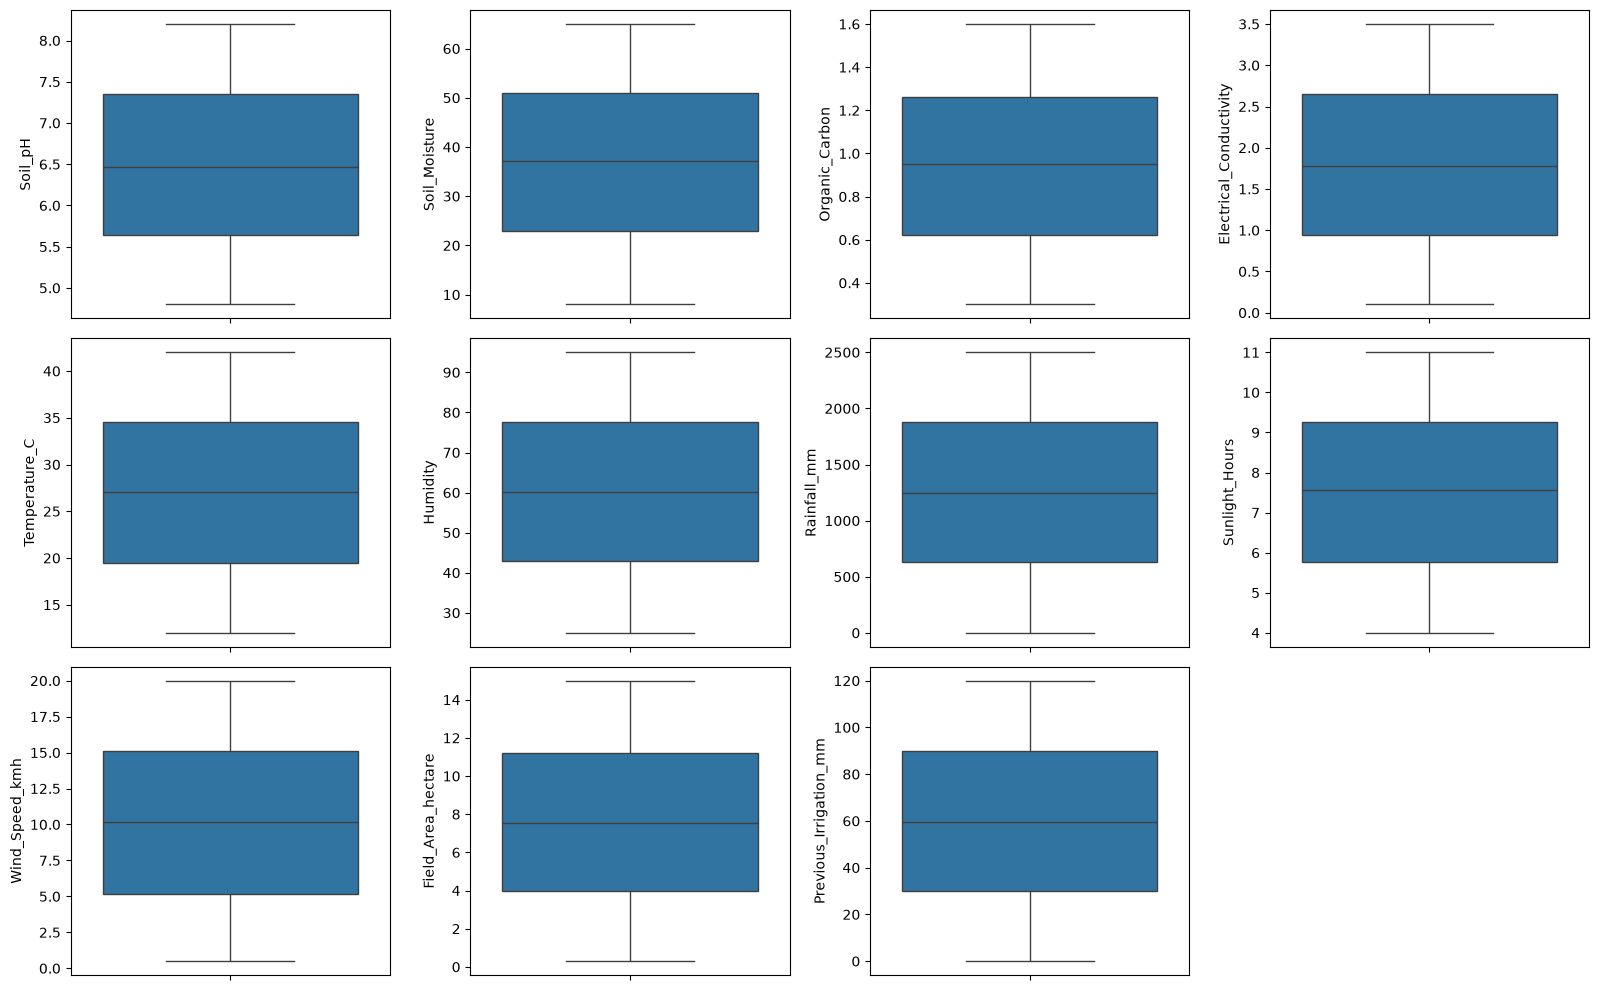

In [14]:
# Visualisation des valeurs extrêmes avec des boxplots
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for i, col in enumerate(variables_numeriques):
    sns.boxplot(y=df[col], ax=axes[i // 4, i % 4])
    # axes[i // 4, i % 4].set_title(col)

# Supprimer le graphique vide
axes[2, 3].set_visible(False)

plt.tight_layout()

plt.savefig("../results/figures/boxplots_var_num.png", dpi=300, bbox_inches="tight")

## 2. Analyse de la variable cible (équilibre des classes)

Irrigation_Need
Low       58.64
Medium    38.00
High       3.36
Name: proportion, dtype: float64


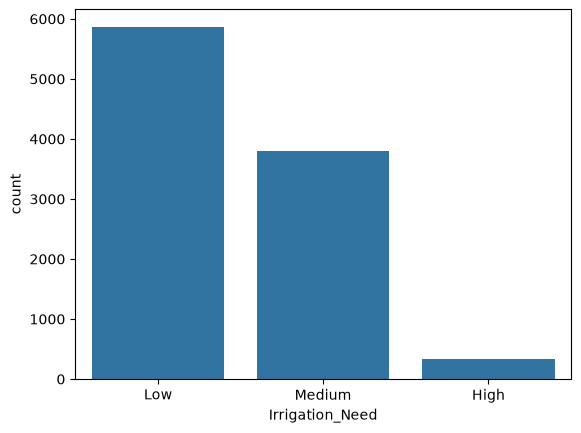

In [15]:
print(df["Irrigation_Need"].value_counts(normalize=True) * 100)
sns.countplot(x="Irrigation_Need", data=df, order=["Low", "Medium", "High"])
plt.savefig("../results/figures/repartition_classes.png")

## 3. Analyse croisée et test d'association (Chi²)

### Interprétation

Seule Crop_Growth_Stage présente une association statistiquement très significative avec Irrigation_Need, confirmant formellement l'observation déjà faite sur le tableau croisé précédent. En revanche, Soil_Type, Season et Region ne montrent aucune association statistique avec la variable cible dans ce jeu de données — un résultat qui doit être signalé explicitement, car il est agronomiquement surprenant : on s'attendrait intuitivement à ce que le type de sol ou la région influencent le besoin en irrigation. Cette absence de lien constitue une limite propre au dataset (possiblement lié à sa nature communautaire/synthétique) à mentionner dans ton mémoire, plutôt qu'un résultat à dissimuler.

In [16]:
from scipy.stats import chi2_contingency

for var in ["Crop_Growth_Stage", "Soil_Type", "Season", "Region"]:
    table = pd.crosstab(df[var], df["Irrigation_Need"])
    chi2, p, dof, exp = chi2_contingency(table)
    display(f"{var} : Chi² = {chi2:.2f}, p-value = {p:.4f}")

'Crop_Growth_Stage : Chi² = 2291.62, p-value = 0.0000'

'Soil_Type : Chi² = 4.21, p-value = 0.6490'

'Season : Chi² = 2.30, p-value = 0.6807'

'Region : Chi² = 5.55, p-value = 0.6970'

## 4. Corrélations entre variables numériques

### Interprétation

Aucune paire de variables numériques ne présente de corrélation significative entre elles. Ce résultat diffère notablement de celui observé chez Lv et al. (2025), où une étape de réduction par corrélation de Spearman était nécessaire pour éliminer des variables redondantes. Ici, l'absence de multicolinéarité signifie qu'aucune variable numérique n'apporte une information dupliquée par rapport à une autre : toutes peuvent potentiellement être conservées sans risque de redondance informationnelle pour le Random Forest.

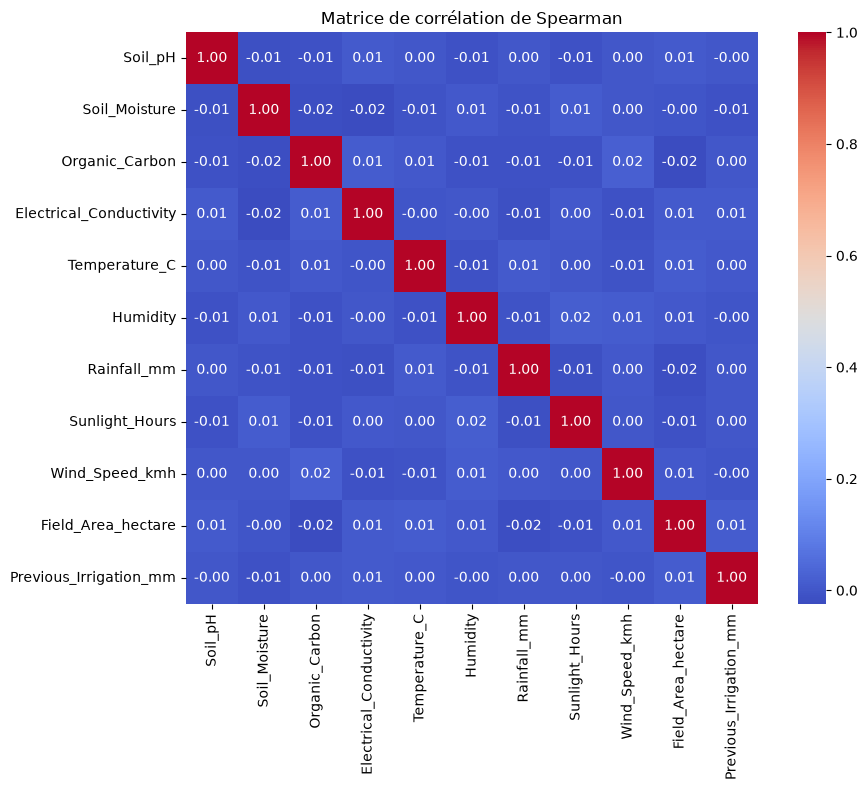

In [17]:
plt.figure(figsize=(10, 8))

corr = df[variables_numeriques].corr(method="spearman")

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Matrice de corrélation de Spearman")
plt.tight_layout()

plt.savefig("../results/figures/correlation_spearman.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Relation entre variables explicatives et variable cible

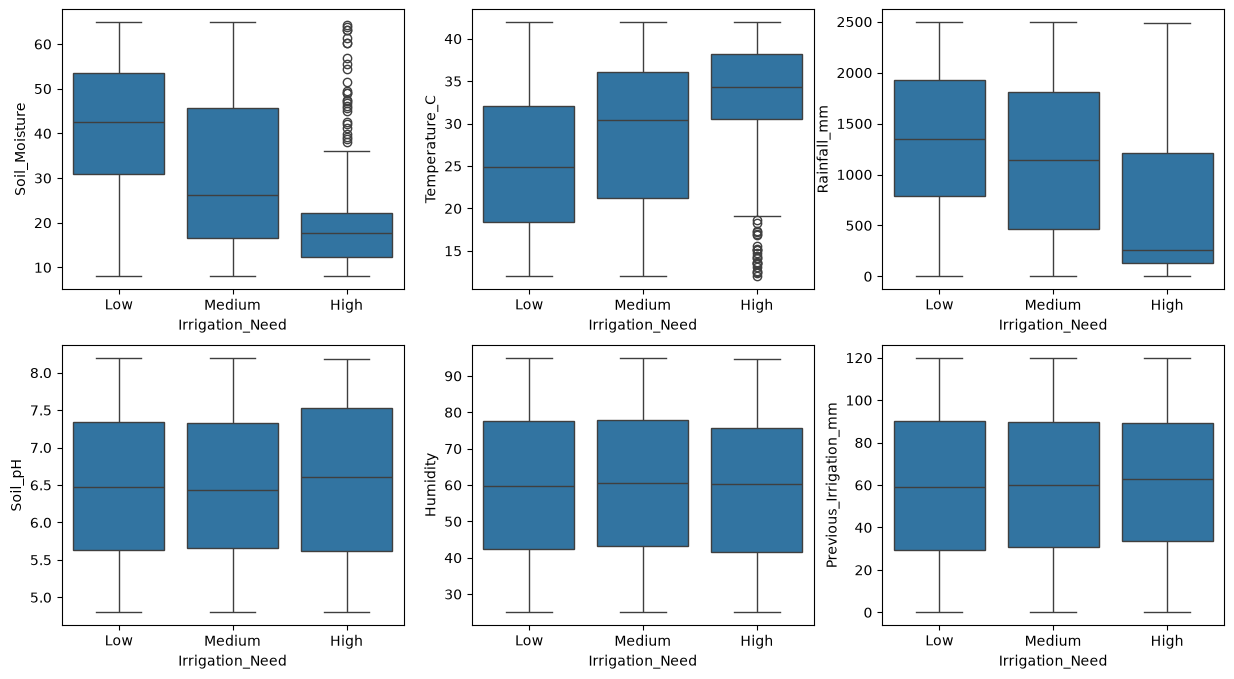

In [18]:
variables_cles = ["Soil_Moisture", "Temperature_C", "Rainfall_mm", 
                   "Soil_pH", "Humidity", "Previous_Irrigation_mm",]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(variables_cles):
    sns.boxplot(x="Irrigation_Need", y=col, data=df, order=["Low", "Medium", "High"], ax=axes[i // 3, i % 3])
plt.savefig("../results/figures/variables_vs_cible.png")

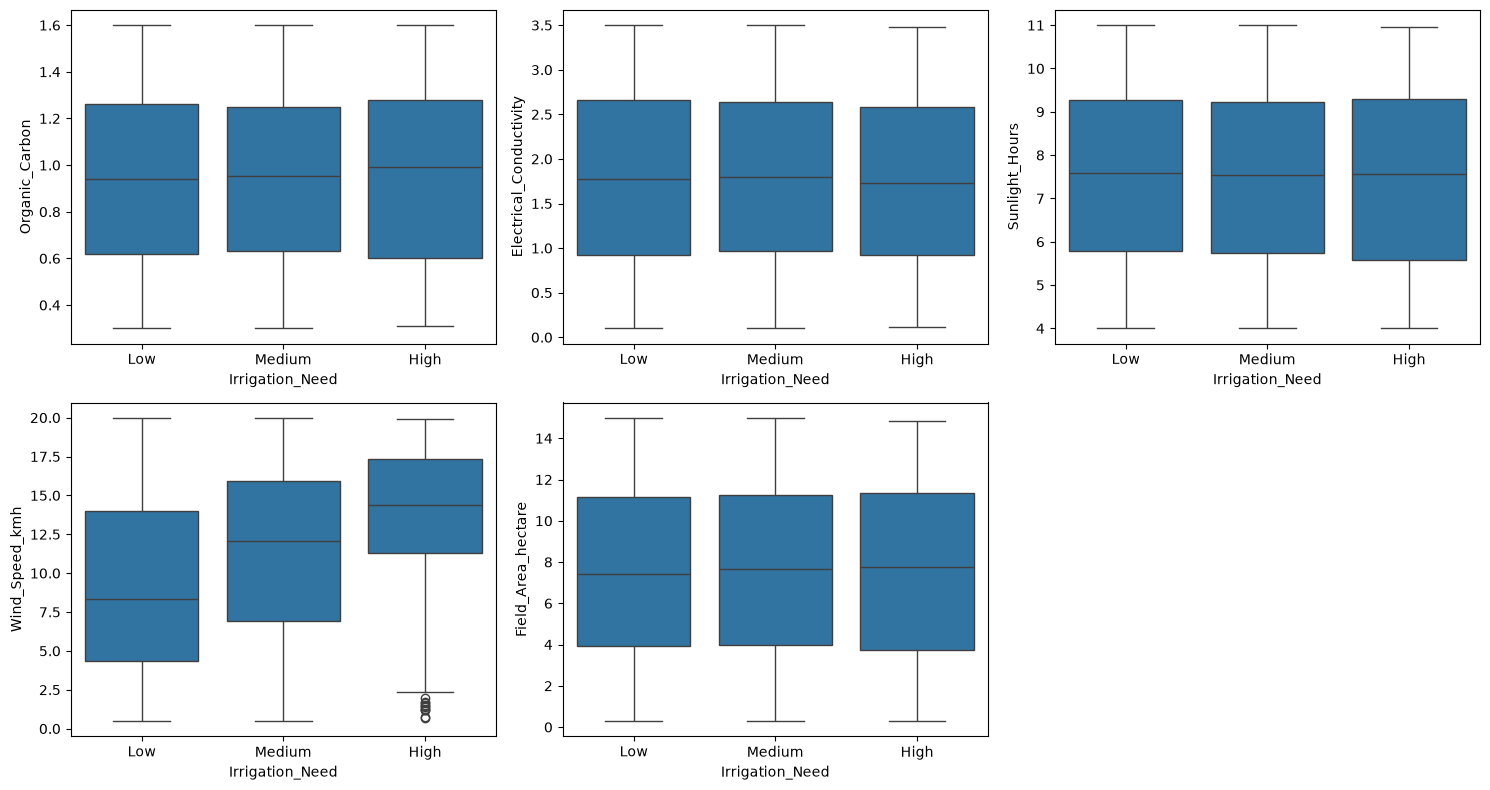

<Figure size 640x480 with 0 Axes>

In [19]:
variables_restantes = ["Organic_Carbon", "Electrical_Conductivity", 
                        "Sunlight_Hours", "Wind_Speed_kmh", "Field_Area_hectare"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(variables_restantes):
    sns.boxplot(x="Irrigation_Need", y=col, data=df, 
                order=["Low", "Medium", "High"], ax=axes[i // 3, i % 3])

# Supprimer le sous-graphique vide (5 variables pour 6 emplacements)
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

plt.savefig("../results/figures/variables_restantes_vs_cible.png")

## 6. Tableau croisé en pourcentages par ligne (pour chaque stade = 100%)

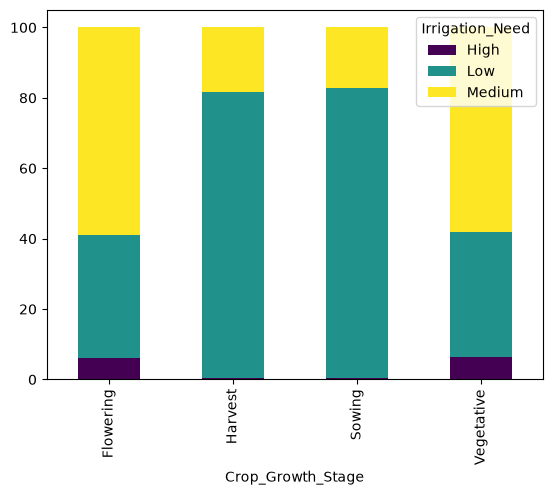

In [20]:
repartition_par_stade = pd.crosstab(
    df["Crop_Growth_Stage"], 
    df["Irrigation_Need"], 
    normalize="index"
) * 100

repartition_par_stade.plot(kind="bar", stacked=True, colormap="viridis")
plt.savefig("../results/figures/repartition_selon_stage.png")

## 7. Séparation train/test

In [21]:
from sklearn.model_selection import train_test_split

# Séparation AVANT toute standardisation et tout clustering
X = df_encoded.drop(columns=["Irrigation_Need", "Irrigation_Need_encoded"])
y = df_encoded["Irrigation_Need_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 8. Normalisation / standardisation des variables numériques

La normalisation doit être maintenue dans le pipeline, mais présentée comme une étape conditionnelle à l'usage en K-means, et non comme une transformation universellement requise — ce qui est plus rigoureux que de la justifier de façon générique.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[variables_numeriques] = scaler.fit_transform(X_train[variables_numeriques])
X_test[variables_numeriques] = scaler.transform(X_test[variables_numeriques])  # transform seul, pas fit

# Random Forest + K-means

## 1. Prétraitement pour le clustering

Conformément à la méthodologie de Bougiouklis et al. (2025), le K-means est appliqué exclusivement sur les variables pédologiques, à l'exclusion des variables environnementales et de la variable cible — l'objectif est de segmenter les parcelles selon leurs propriétés de sol intrinsèques, indépendamment des conditions climatiques ponctuelles ou du besoin en irrigation à prédire

In [23]:
variables_clustering = ["Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity"]

X_train_clustering = X_train[variables_clustering]
X_test_clustering = X_test[variables_clustering]



## 2. Choix du nombre de clusters (K)

### Application de K-mean à différentes valeurs

K selon le coude : 4
K selon la silhouette : 7


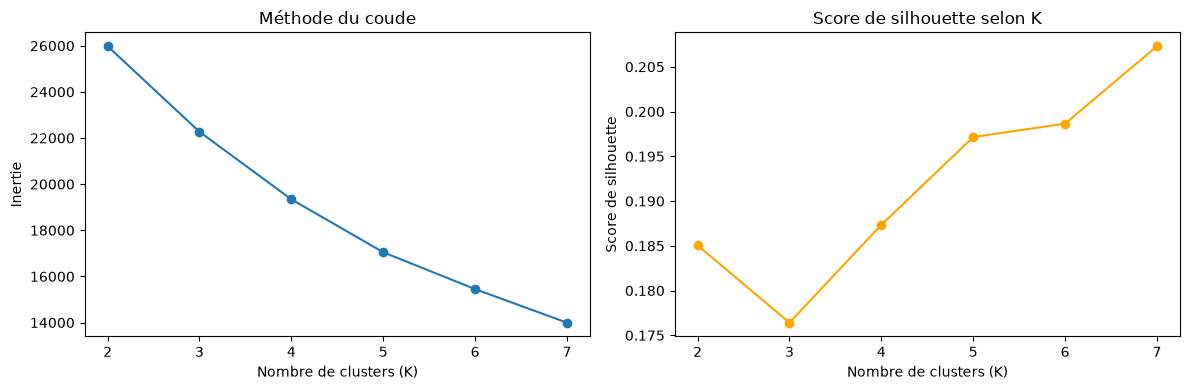

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Recherche des valeurs de K
# ============================================================

inerties = []
scores_silhouette = []
plage_k = range(2, 8)

for k in plage_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_train_clustering)

    inerties.append(kmeans.inertia_)
    scores_silhouette.append(
        silhouette_score(X_train_clustering, labels)
    )

# Méthode du coude
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(plage_k, inerties, marker="o")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")

plt.subplot(1, 2, 2)
plt.plot(plage_k, scores_silhouette, marker="o", color="orange")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon K")

plt.tight_layout()
plt.savefig("../results/figures/choix_k_kmeans.png")

# ============================================================
# 2. K optimal selon la silhouette
# ============================================================

k_silhouette = list(plage_k)[
    np.argmax(scores_silhouette)
]


# ============================================================
# 3. K optimal selon la méthode du coude
# ============================================================

x = np.array(list(plage_k))
y = np.array(inerties)

# Droite reliant le premier et le dernier point
x1, y1 = x[0], y[0]
x2, y2 = x[-1], y[-1]

distances = np.abs(
    (y2 - y1) * x
    - (x2 - x1) * y
    + x2 * y1
    - y2 * x1
) / np.sqrt(
    (y2 - y1)**2 + (x2 - x1)**2
)

k_coude = x[np.argmax(distances)]

print("K selon le coude :", k_coude)
print("K selon la silhouette :", k_silhouette)


# ============================================================
# 4. Variables utilisées pour caractériser les zones
# ============================================================

variables_agronomiques = [
    "Soil_Moisture",
    "Temperature_C",
    "Rainfall_mm",
    "Humidity",
    "Soil_pH"
]


# ============================================================
# 5. Fonction d'analyse d'une segmentation
# ============================================================

def analyser_clustering(k, X, df, variables):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    # Copie temporaire pour ne pas modifier df_encoded
    df_temp = df.copy()
    df_temp["Zone"] = labels

    # Profil moyen de chaque zone
    profil = df_temp.groupby("Zone")[variables].mean()

    # Effectifs
    effectifs = df_temp["Zone"].value_counts().sort_index()

    # Proportion des observations
    proportions = (
        effectifs / len(df_temp) * 100
    ).round(2)

    # Score de silhouette
    silhouette = silhouette_score(X, labels)

    # Écart relatif entre le plus grand et le plus petit cluster
    ratio_taille = effectifs.max() / effectifs.min()

    return {
        "kmeans": kmeans,
        "labels": labels,
        "profil": profil,
        "effectifs": effectifs,
        "proportions": proportions,
        "silhouette": silhouette,
        "ratio_taille": ratio_taille
    }


# ============================================================
# 6. Analyse des deux K candidats
# ============================================================

resultat_coude = analyser_clustering(
    k_coude,
    X_train_clustering,
    X_train,
    variables_agronomiques
)

resultat_silhouette = analyser_clustering(
    k_silhouette,
    X_train_clustering,
    X_train,
    variables_agronomiques
)




In [25]:
def score_differenciation(profil):
    
    # Pour chaque variable :
    # écart entre la valeur maximale et minimale
    ecarts = profil.max() - profil.min()

    # Normalisation par l'écart-type global des profils
    ecarts_normalises = ecarts / profil.std()

    # Moyenne des écarts normalisés
    return ecarts_normalises.mean()

### 1. Analyse selon k_silhouette et k_coude

In [26]:
score_coude = score_differenciation(
    resultat_coude["profil"]
)

score_silhouette = score_differenciation(
    resultat_silhouette["profil"]
)

print("\nScore de différenciation agronomique")
print(f"K = {k_coude} :", round(score_coude, 3))
print(f"K = {k_silhouette} :", round(score_silhouette, 3))


Score de différenciation agronomique
K = 4 : 2.291
K = 7 : 2.544


### 2. K choisi entre k_silhouette et k_coude

In [27]:
# ============================================================
# 8. Score final pour chaque candidat
# ============================================================

def score_final(resultat, score_agronomique, w_sil, w_agro, w_eq):
    
    silhouette = resultat["silhouette"]
    ratio = resultat["ratio_taille"]

    # Plus le ratio est proche de 1, meilleur est l'équilibre
    score_equilibre = 1 / ratio

    # Score global pondéré
    score = (
        w_sil * silhouette
        + w_agro * score_agronomique
        + w_eq * score_equilibre
    )

    return score


In [28]:
scenarios_poids = {
    "Original (0.50/0.30/0.20)": (0.50, 0.30, 0.20),
    "Équilibré (1/3/1/3/1/3)": (1/3, 1/3, 1/3),
    "Silhouette dominant (0.70/0.20/0.10)": (0.70, 0.20, 0.10),
    "Silhouette fort (0.60/0.25/0.15)": (0.60, 0.25, 0.15),
    "Agronomique dominant (0.15/0.70/0.15)": (0.15, 0.70, 0.15),
    "Agronomique fort (0.25/0.60/0.15)": (0.25, 0.60, 0.15),
    "Équilibre dominant (0.20/0.20/0.60)": (0.20, 0.20, 0.60),
    "Équilibre fort (0.25/0.25/0.50)": (0.25, 0.25, 0.50),
    "Silhouette + agronomique (0.45/0.45/0.10)": (0.45, 0.45, 0.10),
    "Agronomique + équilibre (0.15/0.45/0.40)": (0.15, 0.45, 0.40),
    "Silhouette + équilibre (0.45/0.15/0.40)": (0.45, 0.15, 0.40),
}

In [29]:
i = 0
j = 0
for nom, (w_sil, w_agro, w_eq) in scenarios_poids.items():

    score_c = score_final(
        resultat_coude,
        score_coude,
        w_sil,
        w_agro,
        w_eq
    )

    score_s = score_final(
        resultat_silhouette,
        score_silhouette,
        w_sil,
        w_agro,
        w_eq
    )

    if score_c >= score_s:
        K_optimal = k_coude
        i += 1
    else:
        K_optimal = k_silhouette
        j += 1

    print(
        f"{nom} → "
        f"Score K={k_coude} : {score_c:.3f} | "
        f"Score K={k_silhouette} : {score_s:.3f} "
        f"→ K optimal : {K_optimal}"
    )

Original (0.50/0.30/0.20) → Score K=4 : 0.964 | Score K=7 : 1.022 → K optimal : 7
Équilibré (1/3/1/3/1/3) → Score K=4 : 1.132 | Score K=7 : 1.176 → K optimal : 7
Silhouette dominant (0.70/0.20/0.10) → Score K=4 : 0.681 | Score K=7 : 0.732 → K optimal : 7
Silhouette fort (0.60/0.25/0.15) → Score K=4 : 0.823 | Score K=7 : 0.877 → K optimal : 7
Agronomique dominant (0.15/0.70/0.15) → Score K=4 : 1.769 | Score K=7 : 1.929 → K optimal : 7
Agronomique fort (0.25/0.60/0.15) → Score K=4 : 1.559 | Score K=7 : 1.695 → K optimal : 7
Équilibre dominant (0.20/0.20/0.60) → Score K=4 : 1.046 | Score K=7 : 1.016 → K optimal : 4
Équilibre fort (0.25/0.25/0.50) → Score K=4 : 1.078 | Score K=7 : 1.076 → K optimal : 4
Silhouette + agronomique (0.45/0.45/0.10) → Score K=4 : 1.207 | Score K=7 : 1.316 → K optimal : 7
Agronomique + équilibre (0.15/0.45/0.40) → Score K=4 : 1.426 | Score K=7 : 1.487 → K optimal : 7
Silhouette + équilibre (0.45/0.15/0.40) → Score K=4 : 0.795 | Score K=7 : 0.786 → K optimal : 4


In [30]:
# ============================================================
# 10. Clustering final
# ============================================================
K_optimal = k_coude if i > j else k_silhouette

kmeans_final = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
kmeans_final.fit(X_train_clustering)

X_train["Zone"] = kmeans_final.labels_
X_test["Zone"] = kmeans_final.predict(X_test_clustering)  # predict, pas fit_predict


print("\nRépartition finale des zones :")
print(X_train["Zone"].value_counts().sort_index())
print(X_test["Zone"].value_counts().sort_index())



Répartition finale des zones :
Zone
0    1117
1    1311
2    1159
3    1247
4    1097
5    1018
6    1051
Name: count, dtype: int64
Zone
0    295
1    330
2    272
3    311
4    244
5    245
6    303
Name: count, dtype: int64


### 3. Évaluation des clusters de test et train

Comparer le score de silhouette entre train et test permet de vérifier la stabilité de la segmentation — un score très inférieur sur le test indiquerait que les zones définies sur le train généralisent mal à de nouvelles observations. Ce qui n'est pas le cas

In [31]:
score_train = silhouette_score(X_train_clustering, X_train["Zone"])
score_test = silhouette_score(X_test_clustering, X_test["Zone"])

print(f"Score de silhouette (train) : {score_train:.3f}")
print(f"Score de silhouette (test)  : {score_test:.3f}")

Score de silhouette (train) : 0.207
Score de silhouette (test)  : 0.202


## Application : Random Forest

### 1. Préparation des données : Encodage de la nouvelle variable « zone »

In [32]:
# Encodage one-hot de la seule variable nouvelle : Zone (7 modalités, sans ordre)
X_train_B = pd.get_dummies(X_train, columns=["Zone"], prefix="Zone")
X_test_B = pd.get_dummies(X_test, columns=["Zone"], prefix="Zone")

# Alignement des colonnes (sécurité si une zone est absente du test set)
X_train_B, X_test_B = X_train_B.align(X_test_B, join="left", axis=1, fill_value=0)

### 2. Entraînement et validation croisée (réglage des hyperparamètres)

In [33]:
# Vérifier d'abord précisément quelles colonnes posent encore problème
colonnes_texte = X_train_B.select_dtypes(include="string").columns
print("Colonnes non numériques restantes :", list(colonnes_texte))

# Supprimer les colonnes texte devenues redondantes après encodage
X_train_B = X_train_B.drop(columns=colonnes_texte, errors="ignore")
X_test_B = X_test_B.drop(columns=colonnes_texte, errors="ignore")

# Vérification finale : plus aucune colonne non numérique ne doit rester
print(X_train_B.dtypes.value_counts())

Colonnes non numériques restantes : ['Crop_Growth_Stage']
bool       28
float64    11
int64       1
Name: count, dtype: int64


### 4. Graphiques 

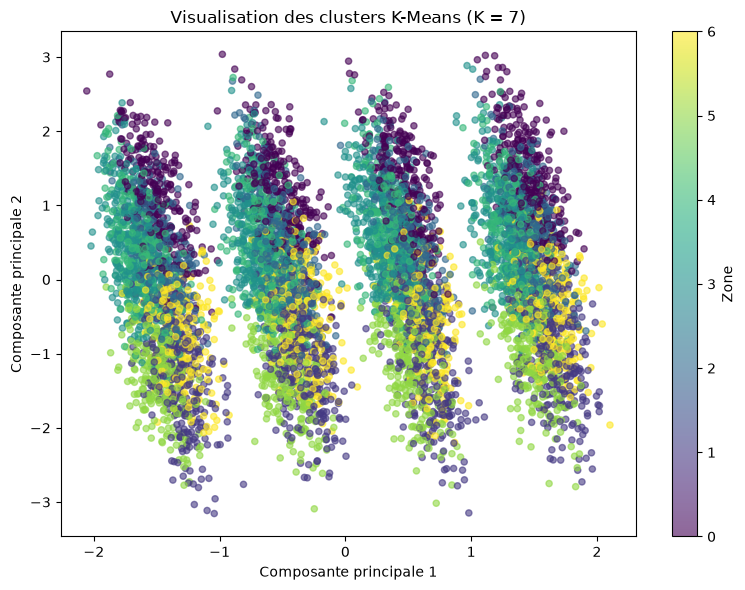

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Réduction à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_B)

# Visualisation des clusters
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=X_train["Zone"],
    s=20,
    alpha=0.6
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title(f"Visualisation des clusters K-Means (K = {K_optimal})")

plt.colorbar(scatter, label="Zone")
plt.tight_layout()
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 5]
}

grid_search_B = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid, cv=5, scoring="f1_macro", n_jobs=-1
)
grid_search_B.fit(X_train_B, y_train)

print(f"Meilleurs hyperparamètres (Random Forest + K-mean) : {grid_search_B.best_params_}")
rf_scenario_B = grid_search_B.best_estimator_

Meilleurs hyperparamètres (Random Forest + K-mean) : {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 600}


### 3. Prédiction et évaluation

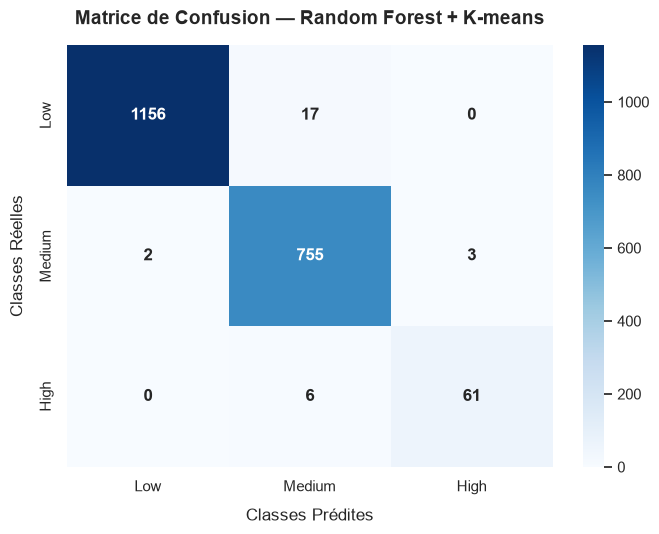

              precision    recall  f1-score   support

         Low       1.00      0.99      0.99      1173
      Medium       0.97      0.99      0.98       760
        High       0.95      0.91      0.93        67

    accuracy                           0.99      2000
   macro avg       0.97      0.96      0.97      2000
weighted avg       0.99      0.99      0.99      2000

F1-score macro (Random Forest + K-means) : 0.968


In [36]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Vos calculs existants
y_pred_B = rf_scenario_B.predict(X_test_B)
cm = confusion_matrix(y_test, y_pred_B)
labels = ["Low", "Medium", "High"]

# Configuration du style graphique
plt.figure(figsize=(7, 5.5))
sns.set_theme(style="white")

# Dessin de la matrice de confusion avec une carte de chaleur (heatmap)
sns.heatmap(
    cm, 
    annot=True,          # Affiche les valeurs numériques au centre
    fmt="d",             # Format des nombres en entiers (pas de notation scientifique)
    cmap="Blues",        # Dégradé de couleurs bleues
    xticklabels=labels,  # Labels sur l'axe X
    yticklabels=labels,  # Labels sur l'axe Y
    cbar=True,           # Affiche la barre d'échelle des couleurs
    annot_kws={"size": 12, "weight": "bold"} # Style du texte dans les cases
)

# Ajout des titres et légendes
plt.title("Matrice de Confusion — Random Forest + K-means", fontsize=14, pad=15, weight="bold")
plt.xlabel("Classes Prédites", fontsize=12, labelpad=10)
plt.ylabel("Classes Réelles", fontsize=12, labelpad=10)
plt.tight_layout() # Évite que les labels soient coupés à l'enregistrement

# Enregistrement de l'image dans le dossier créé
plt.savefig("../results/metrics/m_c_scenario_B.png", dpi=300, bbox_inches="tight")

# 7. Affichage dans le notebook
plt.show()

# Vos affichages textuels d'origine
print(classification_report(y_test, y_pred_B, target_names=labels))
f1_macro_B = f1_score(y_test, y_pred_B, average="macro")
print(f"F1-score macro (Random Forest + K-means) : {f1_macro_B:.3f}")


### 4. Importance des variables (avec attention particulière à Zone)

Importance cumulée des colonnes Zone : 0.0408


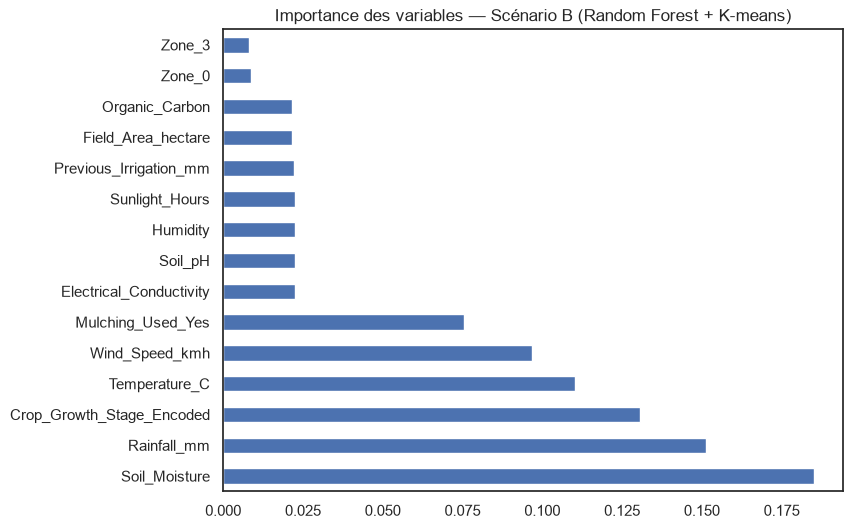

In [37]:
importances_B = pd.Series(rf_scenario_B.feature_importances_, index=X_train_B.columns)
importances_B.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
plt.title("Importance des variables — Scénario B (Random Forest + K-means)")
plt.savefig("../results/figures/importance_variables_scenario_B.png")

# Importance cumulée des seules colonnes Zone
importance_zone_totale = importances_B.filter(like="Zone_").sum()
print(f"Importance cumulée des colonnes Zone : {importance_zone_totale:.4f}")

# Random Forest seul (sans Zone)

In [38]:
# Scénario A : mêmes variables que le scénario B, sans les colonnes Zone_*
colonnes_zone = [col for col in X_train_B.columns if col.startswith("Zone_")]
X_train_A = X_train_B.drop(columns=colonnes_zone)
X_test_A = X_test_B.drop(columns=colonnes_zone)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score

grid_search_A = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid, cv=5, scoring="f1_macro", n_jobs=-1
)
grid_search_A.fit(X_train_A, y_train)
rf_scenario_A = grid_search_A.best_estimator_


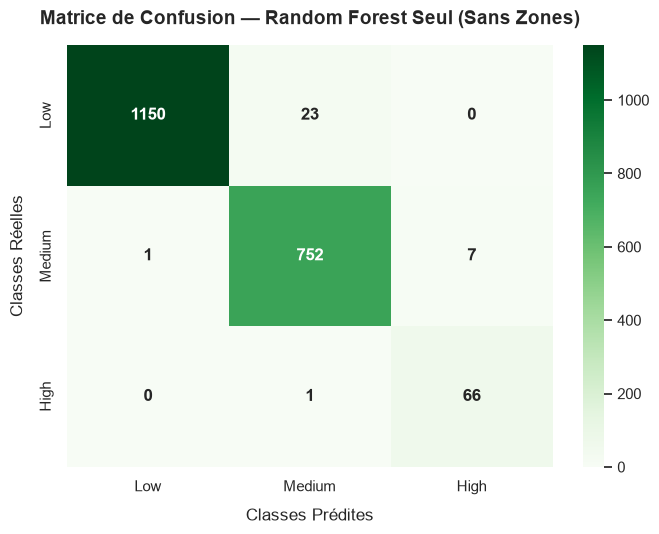

              precision    recall  f1-score   support

         Low       1.00      0.98      0.99      1173
      Medium       0.97      0.99      0.98       760
        High       0.90      0.99      0.94        67

    accuracy                           0.98      2000
   macro avg       0.96      0.98      0.97      2000
weighted avg       0.98      0.98      0.98      2000

F1-score macro (Random Forest Seul (Sans Zones)) : 0.971


In [39]:
# Calcul de la matrice de confusion pour le Scénario A
y_pred_A = rf_scenario_A.predict(X_test_A)
cm_A = confusion_matrix(y_test, y_pred_A)
labels = ["Low", "Medium", "High"]

# Configuration graphique
plt.figure(figsize=(7, 5.5))
sns.set_theme(style="white")

# Dessin de la heatmap (avec un dégradé vert "Greens" pour différencier du Scénario B)
sns.heatmap(
    cm_A, 
    annot=True,          
    fmt="d",             
    cmap="Greens",        # Couleur verte pour le distinguer visuellement du scénario B
    xticklabels=labels,  
    yticklabels=labels,  
    cbar=True,           
    annot_kws={"size": 12, "weight": "bold"} 
)

# itres et axes
plt.title("Matrice de Confusion — Random Forest Seul (Sans Zones)", fontsize=14, pad=15, weight="bold")
plt.xlabel("Classes Prédites", fontsize=12, labelpad=10)
plt.ylabel("Classes Réelles", fontsize=12, labelpad=10)
plt.tight_layout()

# Enregistrement de l'image haute définition
plt.savefig("../results/metrics/m_c_scenario_A.png", dpi=300, bbox_inches="tight")

# Affichage final
plt.show()

# Vos affichages textuels d'origine
print(classification_report(y_test, y_pred_A, target_names=labels))
f1_macro_A = f1_score(y_test, y_pred_A, average="macro")
print(f"F1-score macro (Random Forest Seul (Sans Zones)) : {f1_macro_A:.3f}")

## Importance des variables

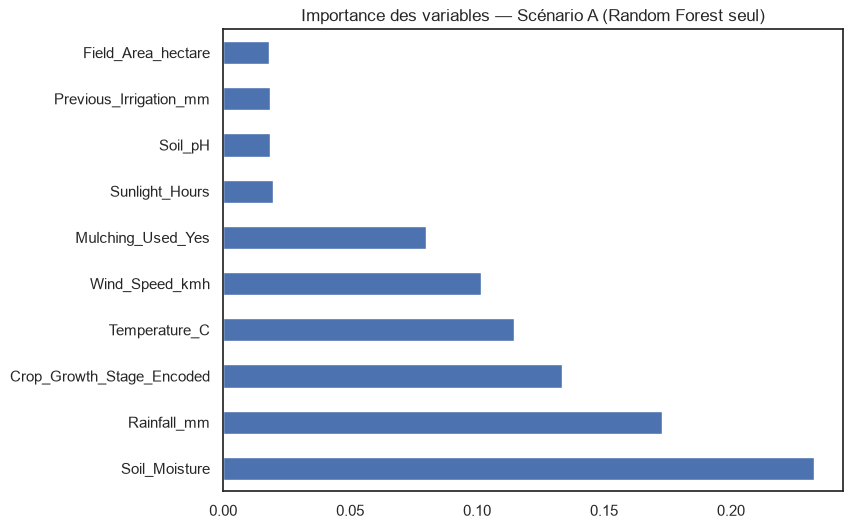

In [40]:
importances_A = pd.Series(rf_scenario_A.feature_importances_, index=X_train_A.columns)
importances_A.sort_values(ascending=False).head(10).plot(kind="barh", figsize=(8, 6))
plt.title("Importance des variables — Scénario A (Random Forest seul)")
plt.savefig("../results/figures/importance_variables_scenario_A.png")